In [72]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import h5py
import scipy
from scipy.optimize import curve_fit

In [2]:
def readInOutputFile(outputFilename):
	optionsStructType = np.dtype([
		('B0', np.float64, 3),
		('E', np.float64, 3),
		('L', np.float64, 3),
		('yi', np.float64, 3),
		('posHistBins', np.float64, 3),
		('m', np.float64),
		('t0', np.float64),
		('tf', np.float64),
		('rtol', np.float64),
		('atol', np.float64),
		('beta', np.float64),
		('uround', np.float64),
		('safe', np.float64),
		('fac1', np.float64),
		('fac2', np.float64),
		('hmax', np.float64),
		('h', np.float64),
		('T', np.float64),
		('gamma', np.float64),
		('V', np.float64),
		('swapStepSize', np.float64),
		('ioutInt', np.float64),
		('nmax', np.uint32),
		('integratorType', np.int32),
		('numParticles', np.int32),
		('numPerGPUBlock', np.int32),
		('iout', np.int32),
		('numPhiBins', np.int32),
		('numThetaBins', np.int32),
		('dist', 'S', 1),
		('output', 'S', 1),
		('gas_coll', bool),
		('diffuse', bool),
		('gravity', bool),
		('pad', 'S', 7) #this is padding space just designed to fix the structure padding done in C++
	])
	file = open(outputFilename, 'rb')
	parameters = np.fromfile(file, count=1, dtype=optionsStructType)[0]
	data = None
	if parameters['output'] == b'n':
		#in this case it was the full dump of all particle data
		outputDtype = np.dtype([
			('t', '<f8'),
			('xx', '<f8'),
			('xy', '<f8'),
			('xz', '<f8'),
			('sx', '<f8'),
			('sy', '<f8'),
			('sz', '<f8')])
		file.seek(0, 0)
		data = np.fromfile(file, dtype=outputDtype, offset=parameters.nbytes)
		numPer = int((parameters['tf']-parameters['t0'])/parameters['ioutInt'])+1
		data = data.reshape(numPer, parameters['numParticles']).T #this returns the data in a little more convenient format, I think
	elif parameters['output'] == b'h':
		#this is the histogram output format instead now
		numx = int(parameters['L'][0]/parameters['gridSize'])+1
		numy = int(parameters['L'][1]/parameters['gridSize'])+1
		numz = int(parameters['L'][2]/parameters['gridSize'])+1
		
		numVecBins = int(np.ceil(2.0/parameters['vecBinSize']))
		
		xbins = np.arange(-parameters['L'][0]/2.0, parameters['L'][0]/2.0, parameters['gridSize'])
		ybins = np.arange(-parameters['L'][0]/2.0, parameters['L'][0]/2.0, parameters['gridSize']) 
		zbins = np.arange(-parameters['L'][0]/2.0, parameters['L'][0]/2.0, parameters['gridSize'])
		sbins = np.arange(-1.0, 1.0, parameters['vecBinSize'])
		outputDtype = np.dtype([
			('t', np.float64),
			('x', np.uint32, numx),
			('y', np.uint32, numy),
			('z', np.uint32, numz),
			('sx', np.uint32, numVecBins),
			('sy', np.uint32, numVecBins),
			('sz', np.uint32, numVecBins)
		])
		file.seek(0, 0)
		data = np.fromfile(file, dtype=outputDtype, offset=parameters.nbytes)
		data = {'xbins': xbins,
			   'ybins': ybins,
			   'zbins': zbins,
			   'sbins': sbins,
			   'data': data}
	elif parameters['output'] == b'a':
		outputDtype = np.dtype([
			('t', np.float64),
			('sx', np.float64),
			('dsx', np.float64),
			('sy', np.float64),
			('dsy', np.float64),
			('sz', np.float64),
			('dsz', np.float64)
		])
		file.seek(0, 0)
		data = np.fromfile(file, dtype=outputDtype, offset=parameters.nbytes)
	file.close()
	return parameters, data

In [33]:
directory = '/netscratch/dmathews33/integratorTesting/'
allFiles = os.listdir(directory)

original = []
compressed = []
goodSize = 308281640
for f in allFiles:
    if os.path.splitext(f)[1] == '.out':
        if f.split('_')[0] == 'int0':
            if os.path.getsize(directory+f) == goodSize:
                original.append(directory+f)
    elif os.path.splitext(f)[1] == '.h5':
        if f.split('_')[0] == 'int0':
            compressed.append(directory+f)

In [125]:
def shiftDatapoints(phis):
    mean = np.mean(phis) #calculate the mean value
    #any values less than the mean by np.pi should be shifted up
    phis[phis<(mean-np.pi)] += 2.0*np.pi
    phis[phis>(mean+np.pi)] -= 2.0*np.pi
    return phis

def analyzeFiles(files, timestamp, bins = np.linspace(-2.0*np.pi, 2.0*np.pi, 10000)):
    output = np.zeros(bins.shape[0]-1)
    allVals = []
    for f in files:
        params, data = readInOutputFile(f)
        phis = np.arctan2(data['sy'][:,timestamp], data['sx'][:,timestamp])
        allVals.append(phis)
    allVals = np.array(allVals)
    shifted = shiftDatapoints(allVals)
    return shifted

In [175]:
bins = np.linspace(-2.0*np.pi, 2.0*np.pi, 10000)
means = []
stds = []
outputs = []
for t in range(0, 21):
    print(t)
    output = analyzeFiles(original, t, bins = bins)
    outputs.append(output)
    b = bins[:-1]
    mean = np.average(output)
    std = np.std(output)
    means.append(mean)
    stds.append(std)
means = np.array(means)
stds = np.array(stds)
outputs = np.array(outputs)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


In [195]:
for n in params.dtype.names:
    print(n, params[n])

B0 [0.e+00 0.e+00 3.e-06]
E [      0.       0. 7500000.]
L [0.07 0.1  0.4 ]
yi [1. 0. 0.]
posHistBins [ 7. 10. 40.]
m 1.1000000000000002e-26
t0 0.0
tf 2000.0
rtol 1e-14
atol 1e-12
beta 0.0
uround 1e-16
safe 0.9
fac1 0.333
fac2 6.0
hmax 1.0
h 0.1
T 0.4
gamma -207800000.0
V 5.0
swapStepSize -3.0
ioutInt 100.0
nmax 10000000
integratorType 0
numParticles 262144
numPerGPUBlock 256
iout 2
numPhiBins 1000
numThetaBins 1000
dist b'C'
output b'n'
gas_coll False
diffuse False
gravity True
pad b''


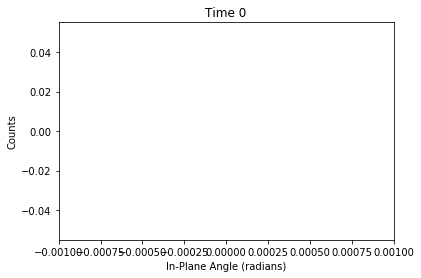

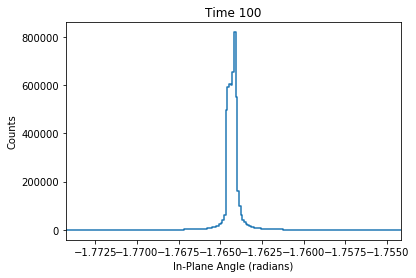

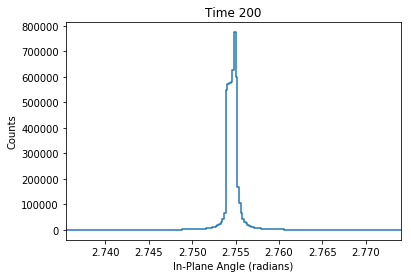

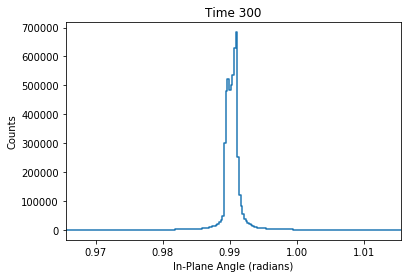

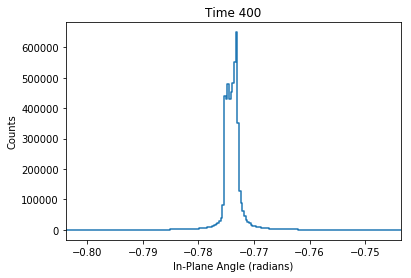

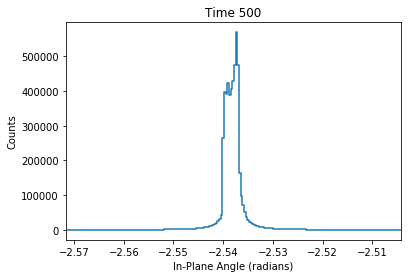

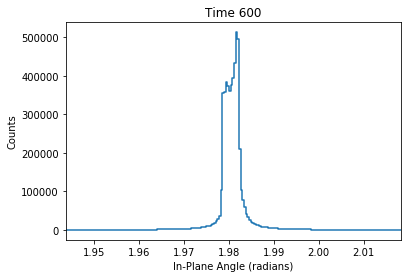

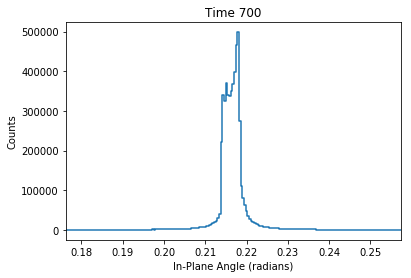

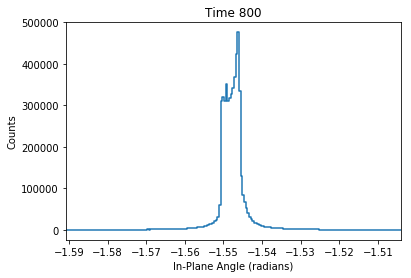

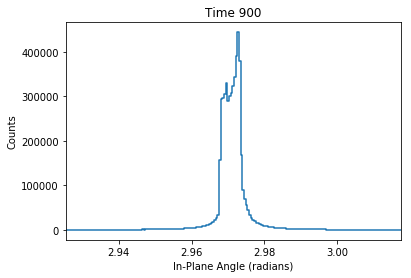

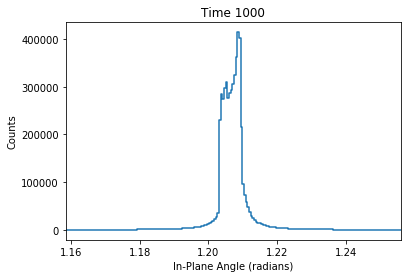

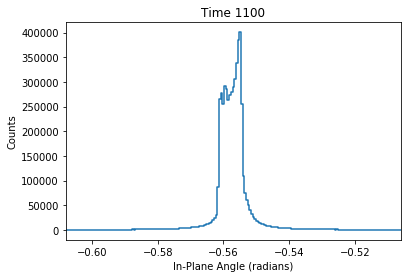

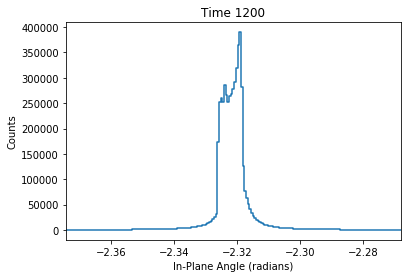

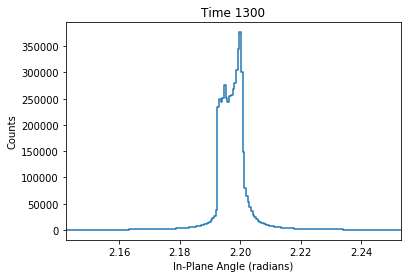

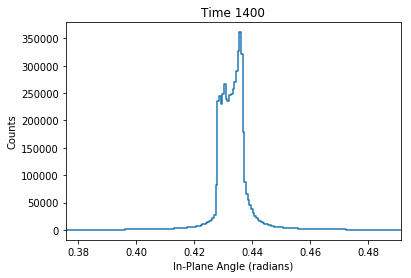

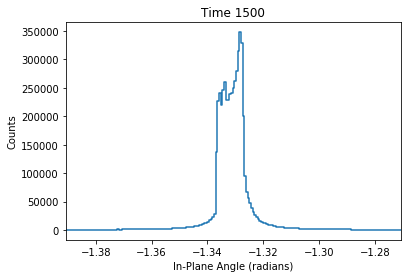

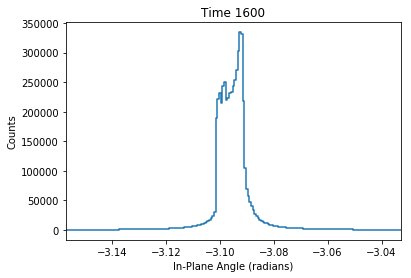

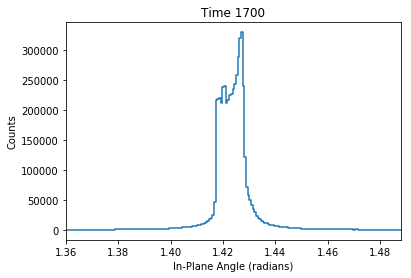

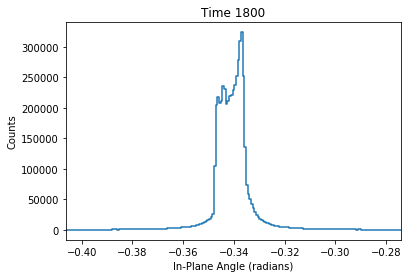

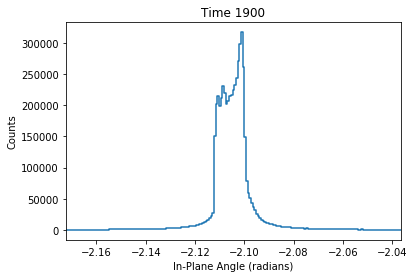

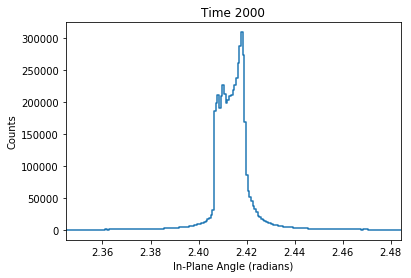

In [194]:
numBins = 400
width = 2
times = np.arange(0, 2100, 100)
for i in range(len(times)):
    out = outputs[i]
    out = out.flatten()
    mean = np.mean(out)
    std = np.std(out)
    valid = out[abs(out-mean)<(std*width)]
    hist, bins = np.histogram(valid, bins = numBins)
    plt.step((bins[:-1]+bins[1:])/2.0, hist)
    #plt.yscale('log')
    plt.xlim(mean-std, mean+std)
    plt.title('Time '+str(times[i]))
    plt.xlabel('In-Plane Angle (radians)')
    plt.ylabel('Counts')
    plt.show()

In [214]:
def bootstrapFit(times, data, numIter, period):
    slopes = []
    offsets = []
    for i in range(numIter):
        print(i)
        means = []
        for j in range(data.shape[0]):
            flat = data[j].flatten()
            samples = np.random.choice(flat, size=flat.shape)
            means.append(np.mean(samples))
        means = np.array(means)
        shiftedMeans = means[:]
        shiftedMeans[shiftedMeans<0] += np.pi*2.0
        locationInPeriod = (times/period)%1
        trueAngle = locationInPeriod*2.0*np.pi
        difference = shiftedMeans - trueAngle
        fitRes = np.polyfit(times, difference, deg=1)
        slopes.append(fitRes[0])
        offsets.append(fitRes[1])
    slopes = np.array(slopes)
    offsets = np.array(offsets)
    return slopes, offsets

In [219]:
slopes, offsets = bootstrapFit(times, outputs, 100, period)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


In [244]:
np.mean(slopes)

3.860534789846933e-06

In [245]:
np.std(slopes)

8.29789721938864e-09

In [247]:
print(w)

-623.4


5242880
[0.e+00 0.e+00 3.e-06] 0.4 [      0.       0. 7500000.] [0.07 0.1  0.4 ]
-623.4 0.010078898471574569


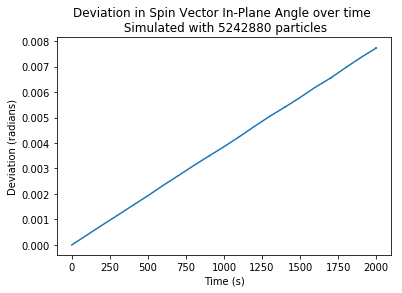

In [198]:
params, data = readInOutputFile(original[0])
numParticles = data.shape[0]*len(original)
print(numParticles)
print(params['B0'], params['T'], params['E'], params['L'])
w = params['gamma']*np.sqrt(np.sum(np.square(params['B0']))) #calculate the frequency
period = abs(2.0*np.pi/w) #calculate the period of the oscillation
print(w, period)
times = np.arange(0, 2100, 100)
locationInPeriod = (times/period)%1
trueAngle = locationInPeriod*2.0*np.pi
shiftedMeans = means[:]
shiftedMeans[shiftedMeans<0] += np.pi*2.0
plt.errorbar(times, shiftedMeans-trueAngle, yerr=stds/np.sqrt(numParticles))
#plt.plot(times, trueAngle)
plt.xlabel('Time (s)')
plt.ylabel('Deviation (radians)')
plt.title('Deviation in Spin Vector In-Plane Angle over time \n Simulated with '+str(numParticles) +' particles')
plt.show()

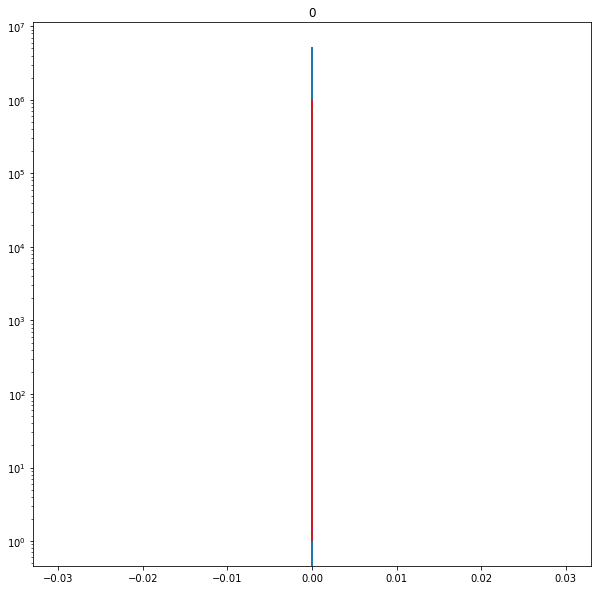

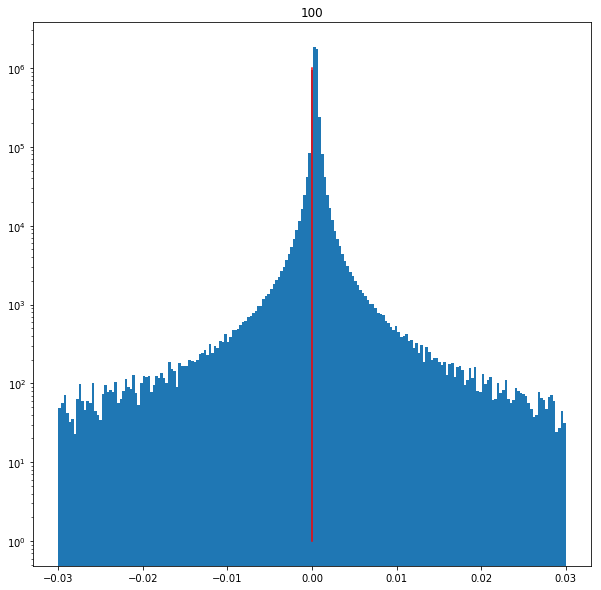

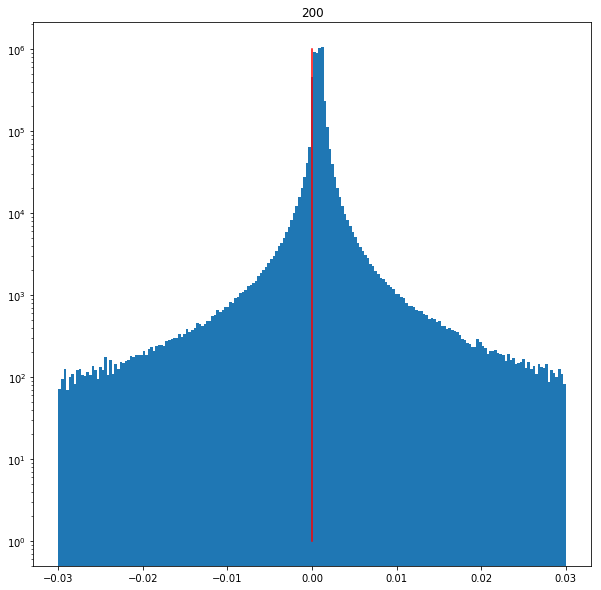

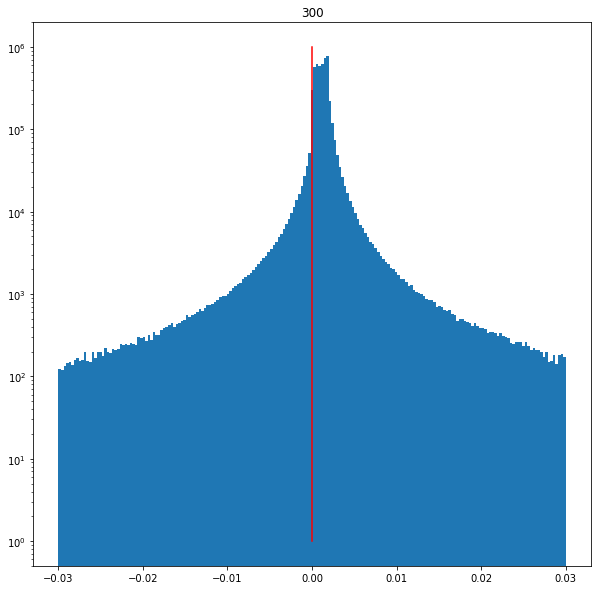

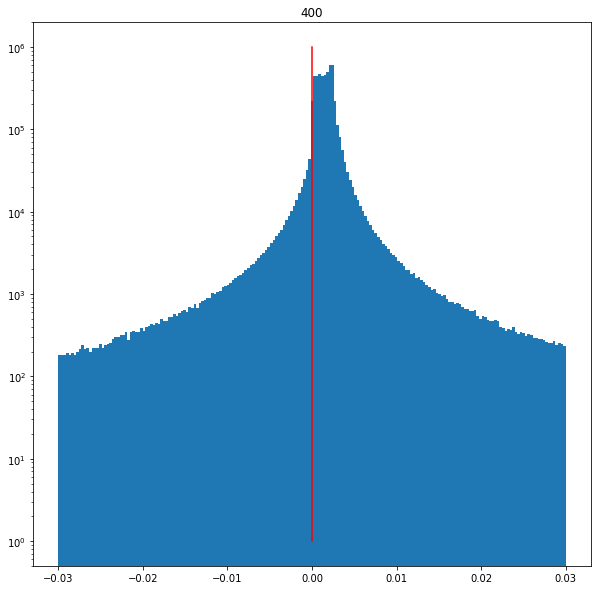

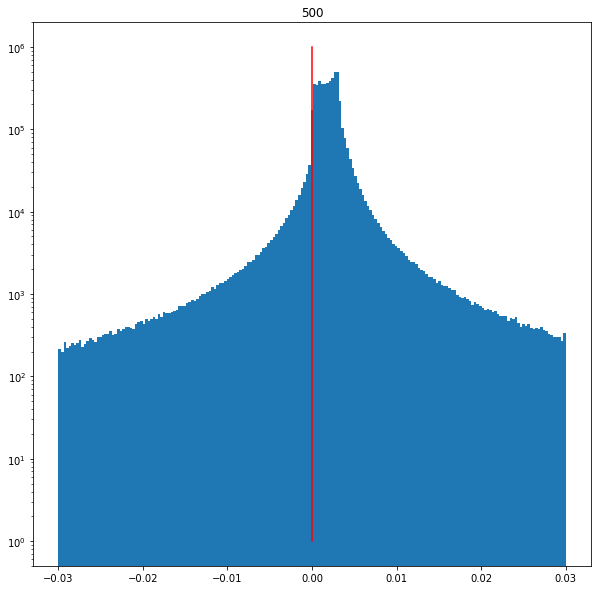

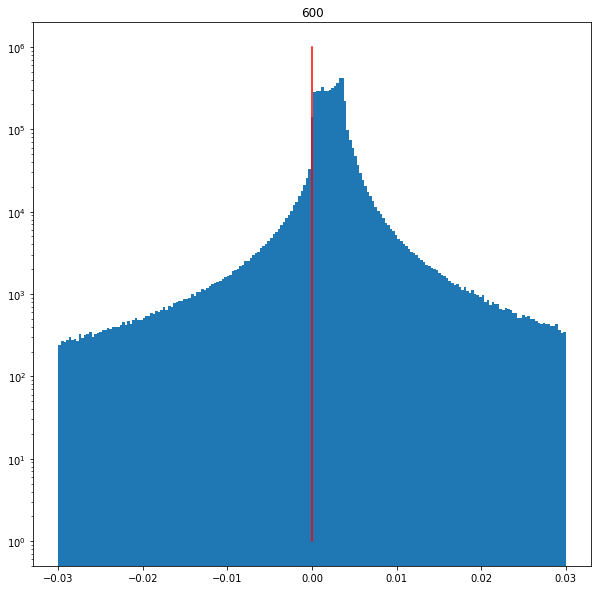

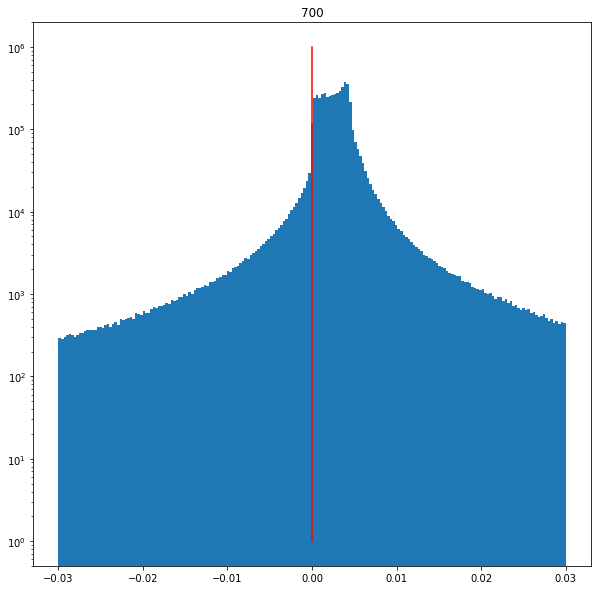

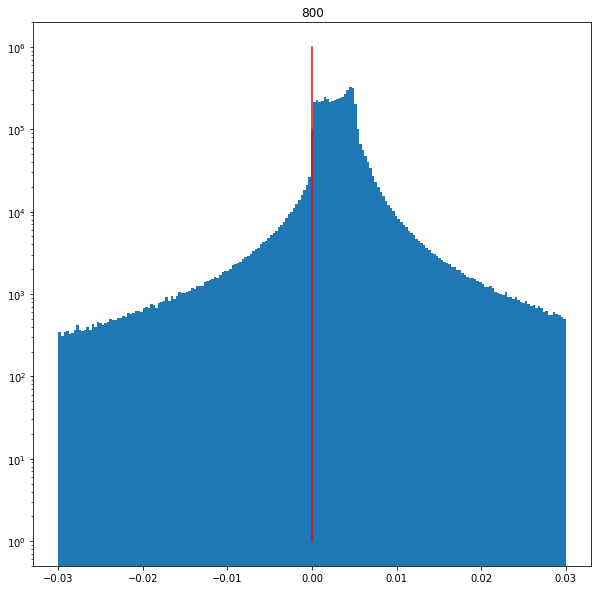

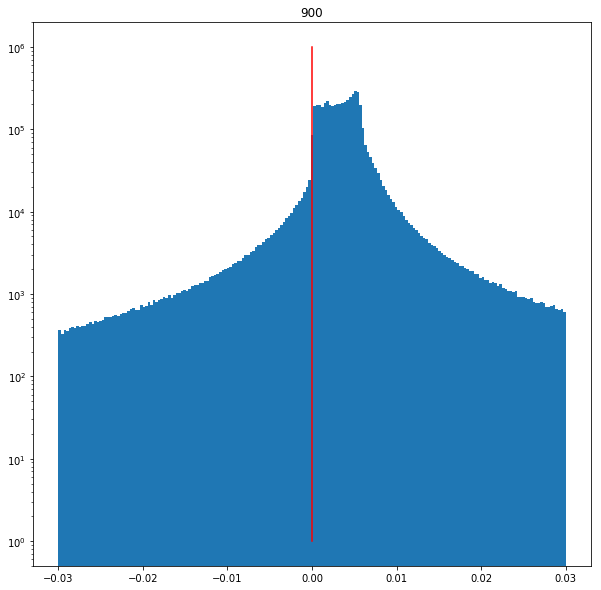

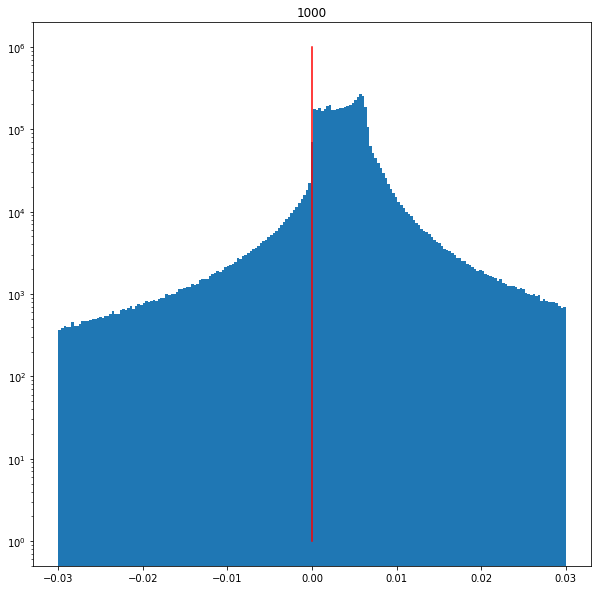

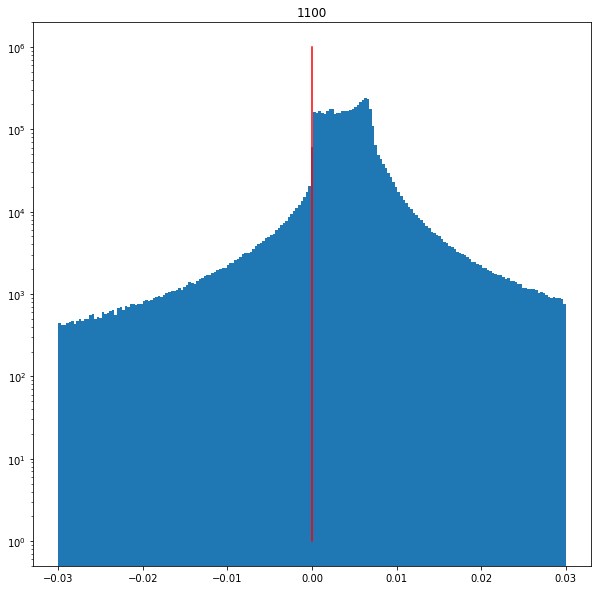

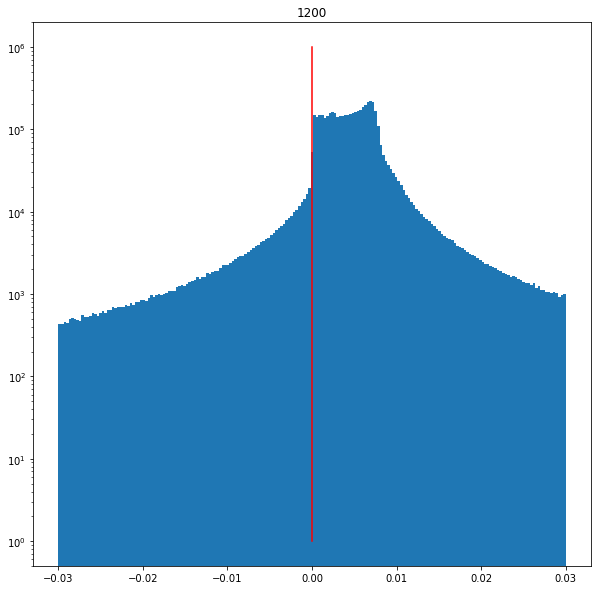

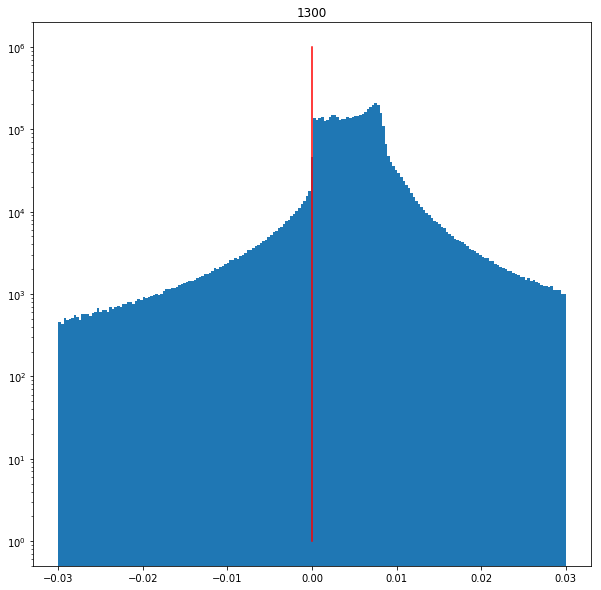

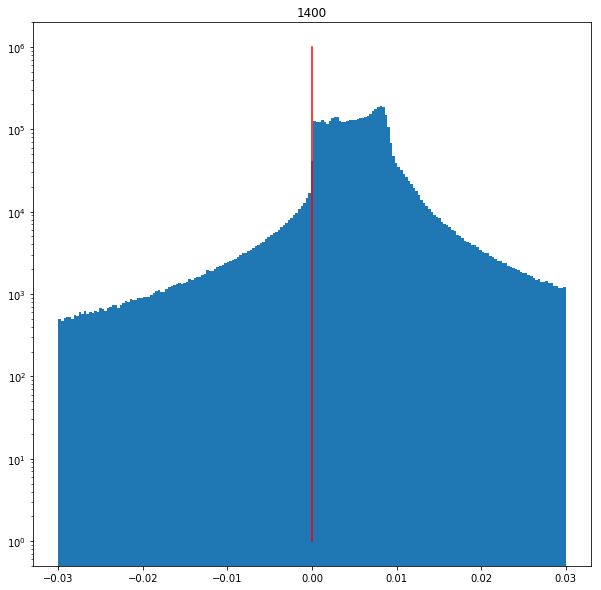

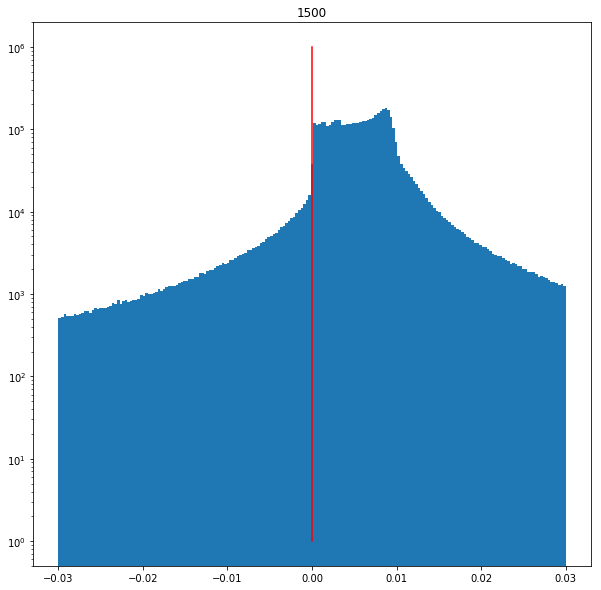

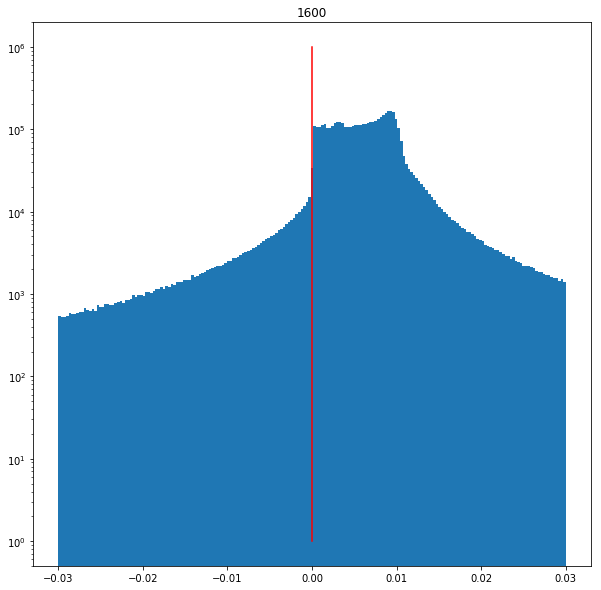

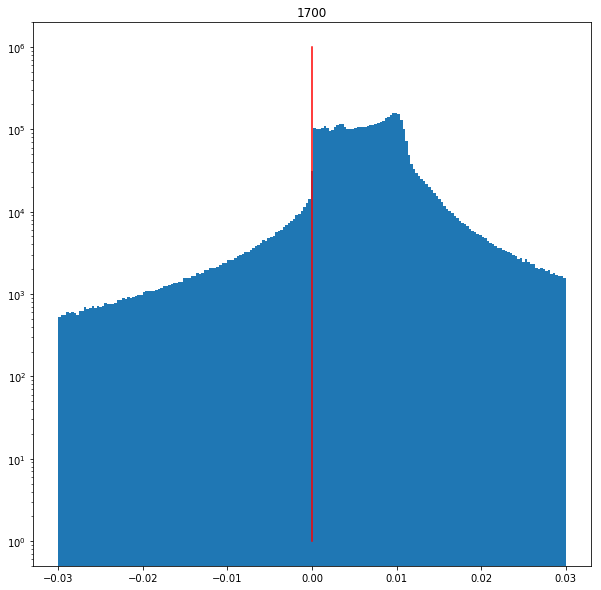

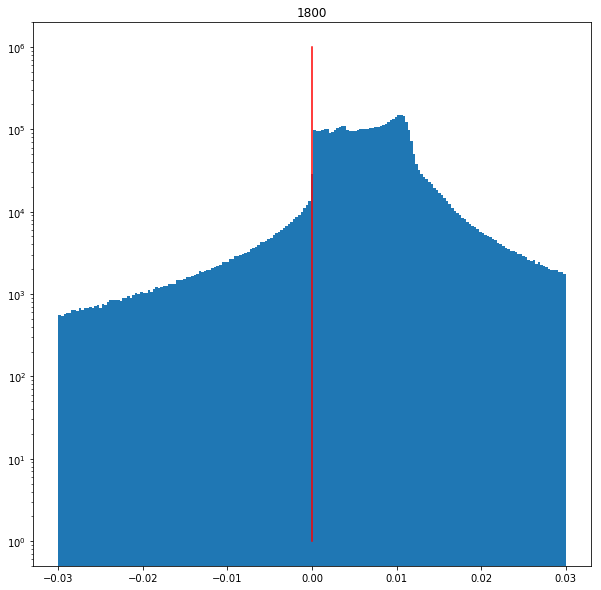

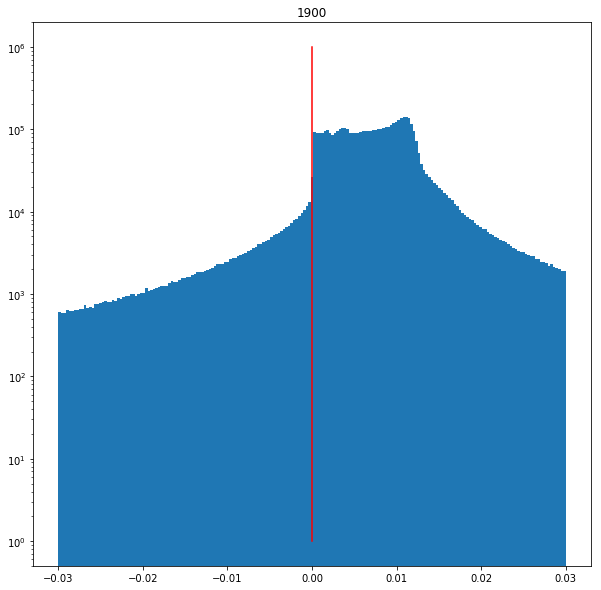

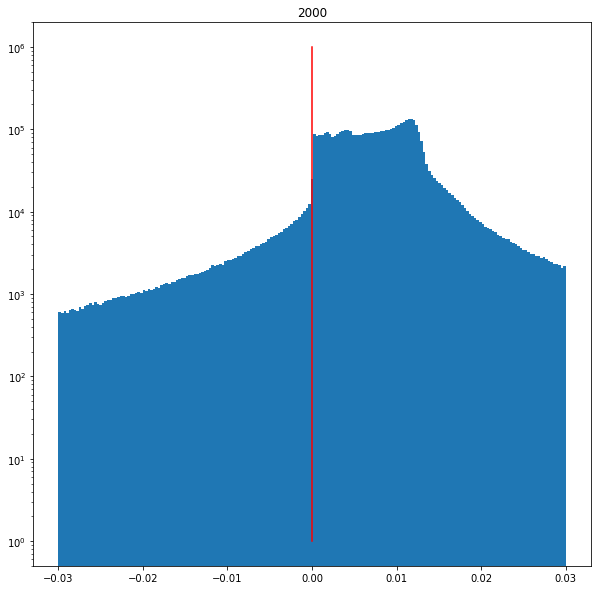

In [243]:
trueAngle = locationInPeriod*2.0*np.pi
bins = np.linspace(-0.03, 0.03, 200)

for i in range(21):
    fig, ax = plt.subplots(figsize=(10, 10))
    out = outputs[i].flatten()-trueAngle[i]
    out[out>np.pi]-=2.0*np.pi
    out[out<-np.pi] += 2.0*np.pi
    plt.hist(out, bins = bins)
    plt.yscale('log')
    plt.title(times[i])
    plt.plot([0, 0], [1, 1.0e6], color='red')
    plt.show()

In [201]:
slope, offset = np.polyfit(times, shiftedMeans-trueAngle, deg=1)
print(slope, offset)

3.861469538904335e-06 5.7908156480744175e-06


In [200]:
for n in params.dtype.names:
    print(n, params[n])

B0 [0.e+00 0.e+00 3.e-06]
E [      0.       0. 7500000.]
L [0.07 0.1  0.4 ]
yi [1. 0. 0.]
posHistBins [ 7. 10. 40.]
m 1.1000000000000002e-26
t0 0.0
tf 2000.0
rtol 1e-14
atol 1e-12
beta 0.0
uround 1e-16
safe 0.9
fac1 0.333
fac2 6.0
hmax 1.0
h 0.1
T 0.4
gamma -207800000.0
V 5.0
swapStepSize -3.0
ioutInt 100.0
nmax 10000000
integratorType 0
numParticles 262144
numPerGPUBlock 256
iout 2
numPhiBins 1000
numThetaBins 1000
dist b'C'
output b'n'
gas_coll False
diffuse False
gravity True
pad b''


In [78]:
bins = np.linspace(-2.0*np.pi, 2.0*np.pi, 10000)[:-1]

In [88]:
mean = np.average(bins, weights=output)
np.average((bins - mean)**2, weights=output)

0.004856562344609788

In [93]:
mean = np.average(bins, weights=output)
std = np.sqrt(np.average((bins - mean)**2, weights=output))
p0 = [0, np.max(output), mean, std]
print(p0)

[0, 540305.0, 2.4138510988806745, 0.06968904034788963]


ValueError: x and y must have same first dimension, but have shapes (10000,) and (20, 262144)

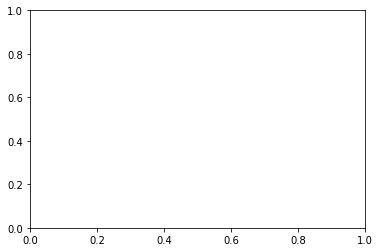

In [153]:
plt.step(bins, output)
plt.step(bins, gauss(bins, *p0))
plt.yscale('log')
plt.ylim(1e1, 1e6)
plt.xlim(2.35, 2.5)
plt.show()

In [234]:
plt.axhline?

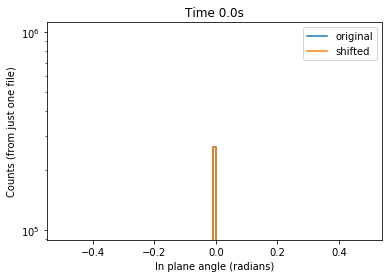

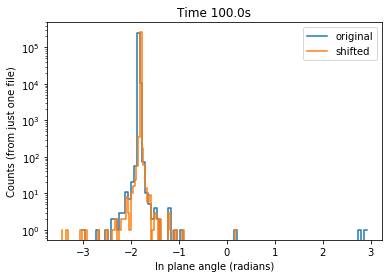

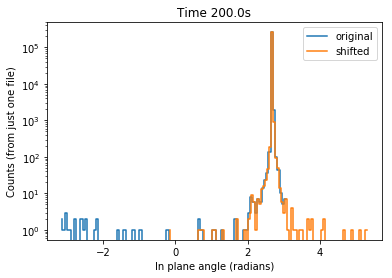

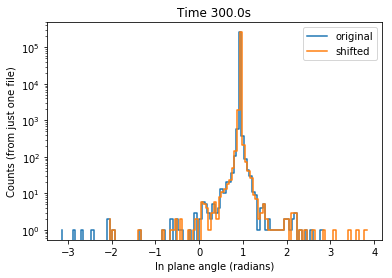

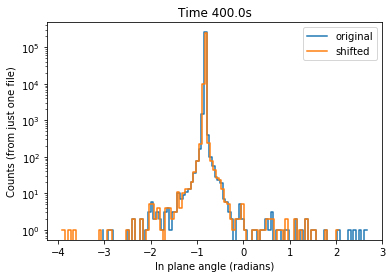

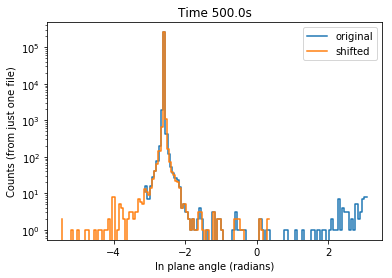

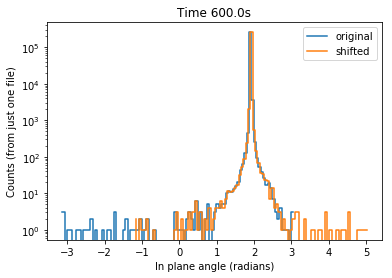

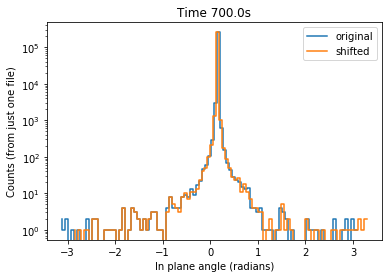

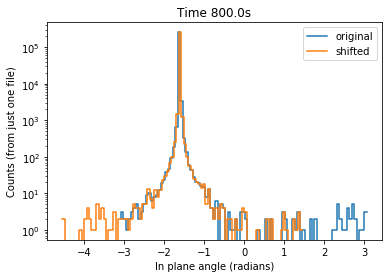

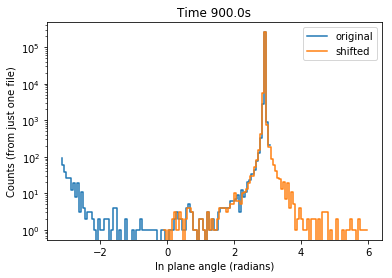

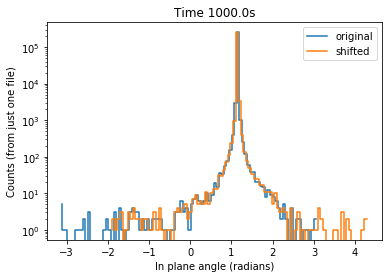

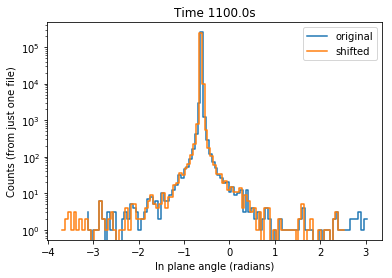

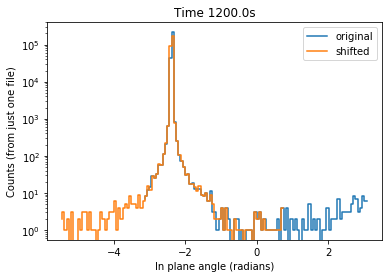

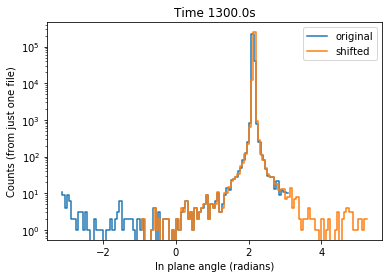

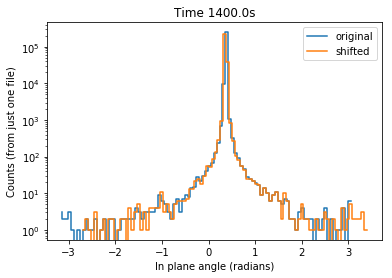

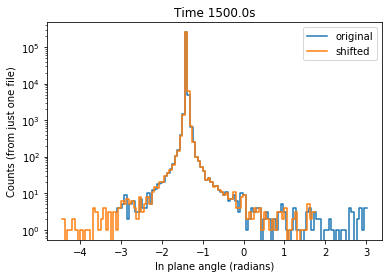

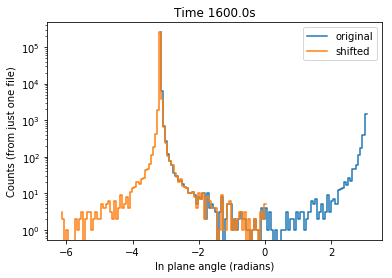

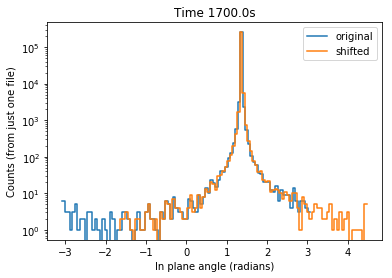

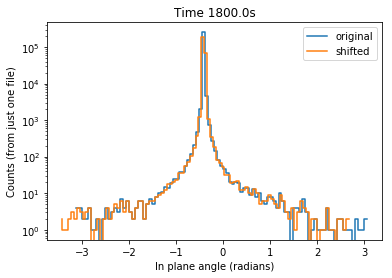

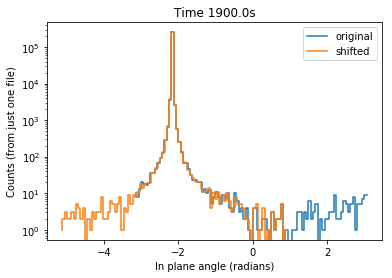

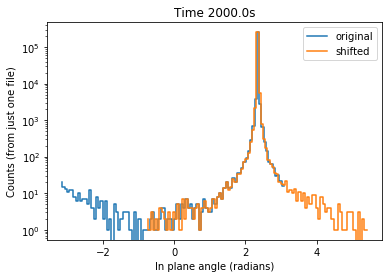

In [54]:
test = readInOutputFile(original[0])    
phis = np.arctan2(test[1]['sy'], test[1]['sx'])
bins = 100

for h in range(phis.shape[1]):
    hist1, bins1 = np.histogram(phis[:,h], bins = bins)
    hist2, bins2 = np.histogram(shiftDatapoints(phis[:,h]), bins)
    plt.step(bins1[:-1], hist1, label='original')
    plt.step(bins2[:-1], hist2, label='shifted')
    plt.yscale('log')
    plt.title('Time '+ str(test[1]['t'][0,h])+'s')
    plt.xlabel("In plane angle (radians)")
    plt.ylabel('Counts (from just one file)')
    plt.legend()
    plt.show()